In [1]:
import numpy as np
import matplotlib.pyplot as plt
from dataclasses import dataclass


In [2]:
def ricker(f, dt, nt):
    t = np.arange(nt) * dt
    t0 = (nt // 2) * dt
    tau = t - t0
    pf2 = (np.pi * f * tau) ** 2
    return (1 - 2 * pf2) * np.exp(-pf2)

def convolve_traces(traces, wavelet):
    nt, nx = traces.shape
    out = np.zeros((nt, nx))
    for ix in range(nx):
        out[:, ix] = np.convolve(traces[:, ix], wavelet, mode='same')
    return out

def agc(traces, win):
    nt, nx = traces.shape
    out = np.zeros_like(traces)
    eps = 1e-6
    ker = np.ones(win) / max(win, 1)
    for ix in range(nx):
        amp = np.sqrt(np.convolve(traces[:, ix]**2, ker, mode='same'))
        out[:, ix] = traces[:, ix] / (amp + eps)
    return out


In [3]:
@dataclass
class Layer:
    v: float
    rho: float

class GeoModel2D:
    def __init__(self, x):
        self.x = x
        self.interfaces = []
        self.layers = []

    @staticmethod
    def horizontal(z):
        return lambda x: np.full_like(x, z, dtype=float)

    @staticmethod
    def inclinada(z0, dip_deg):
        dip = np.deg2rad(dip_deg)
        return lambda x: z0 + np.tan(dip) * (x - x[0])

    @staticmethod
    def anticlinal(z0, amplitud, ancho, x0):
        sigma = ancho / 2.355
        return lambda x: z0 - amplitud * np.exp(-((x - x0) ** 2) / (2 * sigma ** 2))

    @staticmethod
    def sinclinal(z0, amplitud, ancho, x0):
        sigma = ancho / 2.355
        return lambda x: z0 + amplitud * np.exp(-((x - x0) ** 2) / (2 * sigma ** 2))

    @staticmethod
    def aplicar_falla(z_func, x_fault, salto, lado="derecha"):
        def zf(x):
            z = z_func(x)
            if lado == "derecha":
                z = np.where(x >= x_fault, z + salto, z)
            else:
                z = np.where(x <= x_fault, z + salto, z)
            return z
        return zf

    def add_interface(self, z_func):
        self.interfaces.append(z_func)

    def set_layers(self, layers):
        assert len(layers) == len(self.interfaces) + 1, "Capas = interfaces + 1"
        self.layers = layers

    def get_interfaces_z(self):
        return [f(self.x) for f in self.interfaces]

    def reflectivity_series(self):
        Z = [ly.rho * ly.v for ly in self.layers]
        Rs, Zs = [], self.get_interfaces_z()
        for i in range(len(self.interfaces)):
            R = (Z[i+1] - Z[i]) / (Z[i+1] + Z[i])
            Rs.append(np.full_like(self.x, R, dtype=float))
        return Rs, Zs


In [7]:
def wiggle(image, x, t, scale=1.0, fill=True, dx=1.0):
    nt, nx = image.shape
    im = image / (np.max(np.abs(image), axis=0, keepdims=True) + 1e-9)
    for i in range(nx):
        tr = im[:, i] * scale
        plt.plot(x[i] + tr * dx, t, linewidth=0.6)
        if fill:
            plt.fill_betweenx(t, x[i], x[i] + np.maximum(tr, 0) * dx, alpha=0.4, linewidth=0)


In [8]:
def zero_offset_section(model: GeoModel2D, v_eff, dt, tmax, f0, agc_win=None):
    nx = len(model.x)
    nt = int(tmax / dt) + 1
    sec = np.zeros((nt, nx))
    Rs, Zs = model.reflectivity_series()

    for R, z in zip(Rs, Zs):
        t_arr = 2.0 * z / v_eff
        it = np.clip((t_arr / dt).astype(int), 0, nt - 1)
        for ix in range(nx):
            sec[it[ix], ix] += R[ix]

    w = ricker(f0, dt, 201)
    sec = convolve_traces(sec, w)
    if agc_win:
        sec = agc(sec, agc_win)
    return sec

def shot_gather(model: GeoModel2D, v_eff, xs, xr, dt, tmax, f0, agc_win=None):
    nxr = len(xr)
    nt = int(tmax / dt) + 1
    rec = np.zeros((nt, nxr))
    Rs, Zs = model.reflectivity_series()

    for i in range(len(Zs)):
        R = Rs[i]
        z_interface = Zs[i]
        for j in range(nxr):
            xm = 0.5 * (xs + xr[j])
            z_m = np.interp(xm, model.x, z_interface)
            h = 0.5 * (xr[j] - xs)
            t = 2.0 * np.sqrt(z_m**2 + h**2) / v_eff
            it = int(np.round(t / dt))
            if 0 <= it < nt:
                rec[it, j] += np.interp(xm, model.x, R)

    w = ricker(f0, dt, 201)
    rec = convolve_traces(rec, w)
    if agc_win:
        rec = agc(rec, agc_win)
    return rec


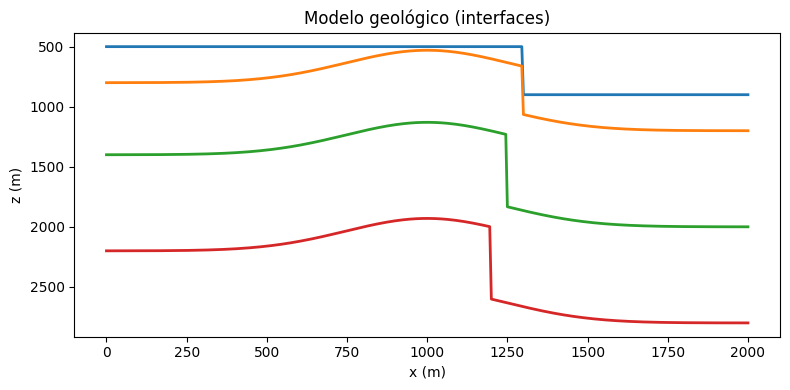

Interfaz 1: R ≈ 0.171
Interfaz 2: R ≈ 0.176
Interfaz 3: R ≈ 0.043
Interfaz 4: R ≈ 0.055


In [50]:
# Eje espacial
x = np.linspace(0, 2000, 401)  # cada 5 m

# Construcción geométrica
gm = GeoModel2D(x)

z1_base = GeoModel2D.horizontal(500)
z1 = GeoModel2D.aplicar_falla(z1_base, x_fault=1300, salto=400, lado="derecha")
z2_base = GeoModel2D.anticlinal(z0=800, amplitud=270, ancho=600, x0=1000)
z2 = GeoModel2D.aplicar_falla(z2_base, x_fault=1300, salto=400, lado="derecha")
z3_base = GeoModel2D.anticlinal(z0=1400, amplitud=270, ancho=600, x0=1000)
z3 = GeoModel2D.aplicar_falla(z3_base, x_fault=1250, salto=600, lado="derecha")
z4_base = GeoModel2D.anticlinal(z0=2200, amplitud=270, ancho=600, x0=1000)
z4 = GeoModel2D.aplicar_falla(z4_base, x_fault=1200, salto=600, lado="derecha")

gm.add_interface(z1)
gm.add_interface(z2)
gm.add_interface(z3)
gm.add_interface(z4)

# Capas (4 capas = 3 interfaces + 1)
#velocidad y densidad de las capas
layers = [
    Layer(v=1800, rho=1900),  # superior
    Layer(v=2300, rho=2100),
    Layer(v=3000, rho=2300),
    Layer(v=3200, rho=2350),
    Layer(v=3500, rho=2400),  # inferior
]
gm.set_layers(layers)

# Visualización del modelo
plt.figure(figsize=(8,4))
for z in gm.get_interfaces_z():
    plt.plot(gm.x, z, linewidth=2)
plt.gca().invert_yaxis()
plt.xlabel('x (m)'); plt.ylabel('z (m)')
plt.title('Modelo geológico (interfaces)')
plt.tight_layout()
plt.show()

# Coeficientes de reflexión (constantes por interfaz en este modelo acústico)
Rs, Zs = gm.reflectivity_series()
for i, R in enumerate(Rs, start=1):
    print(f"Interfaz {i}: R ≈ {R[0]:.3f}")

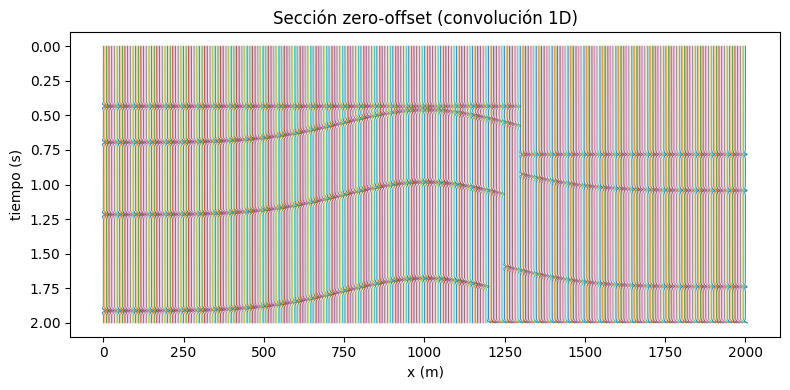

In [44]:
dt = 0.001; tmax = 2.0; f0 = 25.0; v_eff = 2300
zosec = zero_offset_section(gm, v_eff=v_eff, dt=dt, tmax=tmax, f0=f0, agc_win=121)

t = np.arange(zosec.shape[0]) * dt
plt.figure(figsize=(8,4))
wiggle(zosec, x=gm.x, t=t, scale=0.9, fill=True, dx=8)
plt.gca().invert_yaxis()
plt.xlabel('x (m)'); plt.ylabel('tiempo (s)')
plt.title('Sección zero-offset (convolución 1D)')
plt.tight_layout(); plt.show()

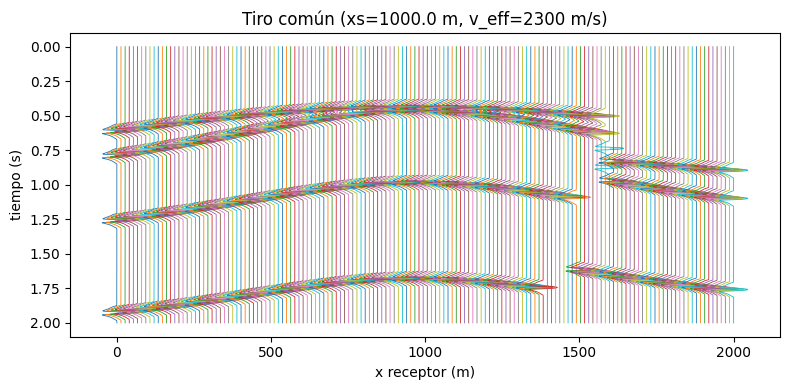

In [45]:
xs = 1000.0 #posicion de la fuente
nR = 150 # numero de receptores
xr = np.linspace(0, 2000, nR)  # receptores
amplitud=5.9 # amplitud grafica del reflector

sg = shot_gather(gm, v_eff=v_eff, xs=xs, xr=xr, dt=dt, tmax=tmax, f0=f0, agc_win=10)

t = np.arange(sg.shape[0]) * dt
plt.figure(figsize=(8,4))

wiggle(sg, x=xr, t=t, scale=amplitud, fill=True, dx=8)
plt.gca().invert_yaxis()
plt.xlabel('x receptor (m)'); plt.ylabel('tiempo (s)')
plt.title(f'Tiro común (xs={xs:.1f} m, v_eff={v_eff} m/s)')
plt.tight_layout(); plt.show()

In [46]:
def shot_gather_with_direct_refrac(model, v_eff, xs, xr, dt, tmax, f0,
                                   amp_directa=0.6, amp_refrac=0.5, agc_win=121):
    # Reflexiones
    rec_ref = shot_gather(model, v_eff=v_eff, xs=xs, xr=xr, dt=dt, tmax=tmax, f0=f0, agc_win=None)

    nxr = len(xr)
    nt = int(tmax / dt) + 1
    imp = np.zeros((nt, nxr))

    Rs, Zs = model.reflectivity_series()
    if len(Zs) == 0:
        v1 = model.layers[0].v
        for j in range(nxr):
            t_d = abs(xr[j] - xs) / v1
            it = int(round(t_d / dt))
            if 0 <= it < nt:
                imp[it, j] += amp_directa
    else:
        v1 = model.layers[0].v
        v2 = model.layers[1].v
        has_head = v2 > v1
        z1_profile = Zs[0]

        for j in range(nxr):
            # Directa
            t_d = abs(xr[j] - xs) / v1
            it = int(round(t_d / dt))
            if 0 <= it < nt:
                imp[it, j] += amp_directa

            # Refractada crítica
            if has_head:
                xm = 0.5 * (xs + xr[j])
                z1 = np.interp(xm, model.x, z1_profile)
                sin_tc = v1 / v2
                if sin_tc < 1.0 and z1 > 0:
                    cos_tc = np.sqrt(1.0 - sin_tc**2)
                    t_i = (2.0 * z1 * cos_tc) / v1
                    t_r = t_i + abs(xr[j] - xs) / v2
                    it_r = int(round(t_r / dt))
                    if 0 <= it_r < nt:
                        imp[it_r, j] += amp_refrac

    w = ricker(f0, dt, 201)
    imp_conv = convolve_traces(imp, w)
    rec_total = rec_ref + imp_conv

    if agc_win:
        rec_total = agc(rec_total, agc_win)
    return rec_total


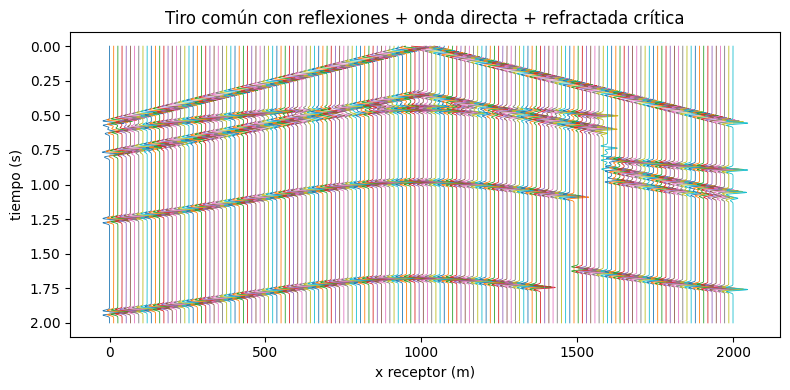

In [47]:
# Ejecutemos el tiro común con directa y refractada
rec_total = shot_gather_with_direct_refrac(gm, v_eff=v_eff, xs=xs, xr=xr, dt=dt, tmax=tmax, f0=f0,
                                           amp_directa=0.6, amp_refrac=0.5, agc_win=121)

t2 = np.arange(rec_total.shape[0]) * dt
plt.figure(figsize=(8,4))
wiggle(rec_total, x=xr, t=t2, scale=amplitud, fill=True, dx=8)
plt.gca().invert_yaxis()
plt.xlabel('x receptor (m)'); plt.ylabel('tiempo (s)')
plt.title('Tiro común con reflexiones + onda directa + refractada crítica')
plt.tight_layout(); plt.show()

In [48]:
def add_ground_roll(xs, xr, dt, nt, v_gr=300.0, f0_gr=8.0, amp=1.0, dispersive=False):
    """Genera una matriz (nt x nxr) con ground roll sintético como impulsos sobre t=|x_r-x_s|/v_gr
    y los filtra con Ricker de baja frecuencia. Si 'dispersive'=True, suma 2–3 componentes
    con distintas velocidades y frecuencias para simular dispersión.

    Devuelve: matriz (nt x nxr) para sumar al registro.
    """
    nxr = len(xr)
    gr_imp = np.zeros((nt, nxr))

    if not dispersive:
        # no dispersivo: una sola rama
        for j in range(nxr):
            t_gr = abs(xr[j] - xs) / v_gr
            it = int(round(t_gr / dt))
            if 0 <= it < nt:
                gr_imp[it, j] += amp
        # Ricker baja frecuencia
        tlen = min(201, nt//2*2+1)
        w = ricker(f0_gr, dt, tlen)
        return convolve_traces(gr_imp, w)
    else:
        # dispersivo: suma de varias ramas (f0 y v cambian)
        comps = [(6.0, v_gr*0.8, amp*0.7),
                 (9.0, v_gr*1.0, amp*0.5),
                 (12.0, v_gr*1.3, amp*0.4)]
        out = np.zeros((nt, nxr))
        for f0_c, v_c, a_c in comps:
            tmp = np.zeros((nt, nxr))
            for j in range(nxr):
                t_gr = abs(xr[j] - xs) / v_c
                it = int(round(t_gr / dt))
                if 0 <= it < nt:
                    tmp[it, j] += a_c
            tlen = min(201, nt//2*2+1)
            w = ricker(f0_c, dt, tlen)
            out += convolve_traces(tmp, w)
        return out

def apply_attenuation(traces, dt, geom=True, Q=None, f_c=None):
    """Aplica atenuación dependiente del tiempo:

    - geom=True → factor geométrico ~ 1/sqrt(t)

    - Q (opcional) con frecuencia efectiva f_c → exp(-alpha*t), alpha=pi*f_c/Q

    Devuelve: nueva matriz atenuada.

    """
    nt, nx = traces.shape
    t = np.arange(nt) * dt
    out = traces.copy()
    eps = 1e-6
    if geom:
        geo = 1.0 / np.sqrt(t + eps)
        out = out * geo[:, None]
    if Q is not None and f_c is not None and Q > 0:
        alpha = np.pi * f_c / Q
        anel = np.exp(-alpha * t)
        out = out * anel[:, None]
    return out

def fk_mute_low_velocity(traces, dt, dx, vmin, taper=0.1):
    """Mute en f–k para eliminar energía con velocidad de fase v < vmin.

    - FFT 2D (t,x) → (f,kx); máscara según v_phase = 2π f / |kx| < vmin.

    - 'taper' define franja de transición relativa.

    Devuelve: trazas filtradas (real).

    """
    nt, nx = traces.shape
    # FFT en tiempo y espacio
    TR = np.fft.fft2(traces, s=(nt, nx))
    f = np.fft.fftfreq(nt, d=dt)      # Hz
    kx = np.fft.fftfreq(nx, d=dx) * 2*np.pi  # rad/m
    F, KX = np.meshgrid(f, kx, indexing='xy')  # (nx, nt) si no cuidamos; rehagamos para (nt,nx)
    # Queremos F (nt, nx) y KX (nt, nx)
    F = np.fft.fftfreq(nt, d=dt)[:, None]      # (nt,1)
    KX = (np.fft.fftfreq(nx, d=dx) * 2*np.pi)[None, :]  # (1,nx)
    F_mat = np.tile(F, (1, nx))   # (nt,nx)
    K_mat = np.tile(KX, (nt, 1))  # (nt,nx)

    eps = 1e-9
    v_phase = (2*np.pi*np.abs(F_mat)) / (np.abs(K_mat) + eps)  # m/s
    # Máscara: mantener solo v_phase >= vmin (mute bajas velocidades)
    mask = np.ones_like(v_phase)
    hard = v_phase >= vmin
    soft = (v_phase >= vmin*(1-taper)) & (v_phase < vmin)
    mask[~hard & ~soft] = 0.0
    # Taper lineal en zona soft
    mask[soft] = (v_phase[soft] - vmin*(1-taper)) / (vmin*taper)

    # Aplicar máscara respetando simetría conjugada
    TR_filtered = TR * mask
    out = np.fft.ifft2(TR_filtered).real
    return out


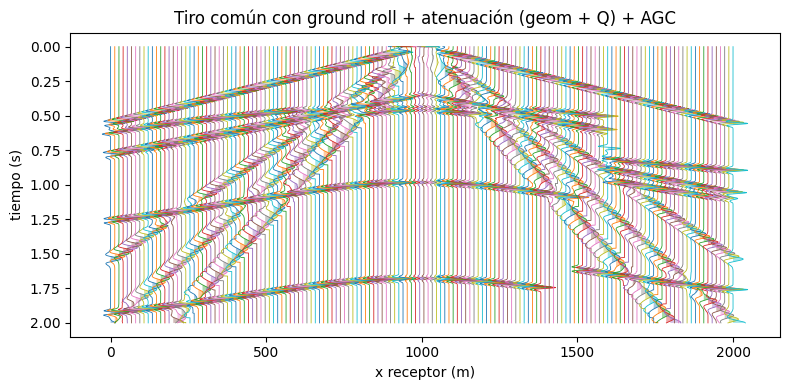

In [49]:
# Parámetros para ground roll y atenuación
v_gr = 500.0         # m/s (velocidad aparente baja)
f0_gr = 8.0          # Hz (baja frecuencia)
amp_gr = 1.0         # amplitud relativa
use_dispersive = True

# Construir ground roll
nt = int(tmax / dt) + 1
gr = add_ground_roll(xs, xr, dt, nt, v_gr=v_gr, f0_gr=f0_gr, amp=amp_gr, dispersive=use_dispersive)

# Registro base con reflexiones (y directa/refractada si ya las sumaste en 'rec_total')
# Si no existe 'rec_total', usamos 'sg' (solo reflexiones del tiro común)
try:
    base = rec_total.copy()
except NameError:
    base = sg.copy()

reg_con_gr = base + gr

# Atenuación (antes de AGC): geométrica + Q
Q = 120.0
f_c = f0  # aproximamos con frecuencia pico de la Ricker principal
reg_atenuado = apply_attenuation(reg_con_gr, dt, geom=True, Q=Q, f_c=f_c)

# AGC para visualización
reg_agc = agc(reg_atenuado, win=121)

# Graficar
t = np.arange(nt) * dt
plt.figure(figsize=(8,4))
wiggle(reg_agc, x=xr, t=t, scale=amplitud, fill=True, dx=8)
plt.gca().invert_yaxis()
plt.xlabel('x receptor (m)'); plt.ylabel('tiempo (s)')
plt.title('Tiro común con ground roll + atenuación (geom + Q) + AGC')
plt.tight_layout(); plt.show()

## Experimentos sugeridos
1. Cambia geometría (sinclinal, capa inclinada extra). ¿Cómo cambia la sección?
2. Mueve la falla y el salto. Observa continuidad de reflectores.
3. Varía \(v_{eff}\). Observa la curvatura de hipérbolas.
4. Cambia \(f_0\) (Ricker). Compara alta vs. baja frecuencia.
5. Cambia amplitud de directa/refractada. ¿Cuándo dominan?
